<a href="https://colab.research.google.com/github/Landsonvictor/analise-ideb-2023-fortaleza/blob/main/ARTIGO_IDEB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMUNICAÇÃO GIT HUB

In [ ]:
# Clonar repositório
!git clone https://github.com/Landsonvictor/analise-ideb-2023-fortaleza.git
%cd /content/analise-ideb-2023-fortaleza


Cloning into 'analise-ideb-2023-fortaleza'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 97 (delta 11), reused 76 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 2.99 MiB | 30.95 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/analise-ideb-2023-fortaleza
'~$TABELA ARTIGO.xlsx'
'Cronograma  Artigo.docx'
 dados
 dicionário_dados_educação_básica.xlsx
 Imagens
'Indicadores de avaliação de contexto e desempenho no Ideb_ uma análise das escolas municipais de ensino fundamental II de Fortaleza em 2023.docx'
 README.md
 REFERENCIAS
'TABELA ARTIGO.xlsx'


In [ ]:
# ENVIAR PRO GIT HUB
'''
%cd /content/analise-ideb-2023-fortaleza

!git add .
!git commit -m "Atualização via Colab"
!git push
'''

[Errno 2] No such file or directory: '/content/analise-ideb-2023-fortaleza'
/content
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


# BIBLIOTECAS E CAMINHOS


In [ ]:
#  Importar Bibliotecas
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Caminhos base
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados"

DADOS_RECORTADOS = os.path.join(BASE_DIR, "DADOS_RECORTADOS")
DADOS_TRATADOS = os.path.join(BASE_DIR, "DADOS_TRATADOS")
DADOS_UNIFICADOS = os.path.join(BASE_DIR, "DADOS_UNIFICADOS")

# Criar pastas se não existirem
os.makedirs(DADOS_TRATADOS, exist_ok=True)
os.makedirs(DADOS_UNIFICADOS, exist_ok=True)

In [ ]:
# Caminho da pasta onde estão os arquivos
PASTA_ORIGEM = "/content/analise-ideb-2023-fortaleza/dados/DADOS_RECORTADOS"

# Pasta destino (CSV)
PASTA_DESTINO = "/content/analise-ideb-2023-fortaleza/dados/DADOS_RECORTADOS"

os.makedirs(PASTA_DESTINO, exist_ok=True)

# Loop em todos os arquivos
for arquivo in os.listdir(PASTA_ORIGEM):
    if arquivo.endswith(".xlsx"):
        caminho_excel = os.path.join(PASTA_ORIGEM, arquivo)

        # Ler Excel
        df = pd.read_excel(caminho_excel)

        # Nome do CSV
        nome_csv = arquivo.replace(".xlsx", ".csv")
        caminho_csv = os.path.join(PASTA_DESTINO, nome_csv)

        # Salvar CSV
        df.to_csv(caminho_csv, index=False, sep=";", encoding="latin1")

        print(f"Convertido: {arquivo} → {nome_csv}")

Convertido: AFD_RECORTADO.xlsx → AFD_RECORTADO.csv
Convertido: SPAECE_MAT_RECORTADO.xlsx → SPAECE_MAT_RECORTADO.csv
Convertido: ATU_RECORTADO.xlsx → ATU_RECORTADO.csv
Convertido: IRD_RECORTADO.xlsx → IRD_RECORTADO.csv
Convertido: DSU_RECORTADO.xlsx → DSU_RECORTADO.csv
Convertido: IDEB_RECORTADO.xlsx → IDEB_RECORTADO.csv
Convertido: HAD_RECORTADO.xlsx → HAD_RECORTADO.csv
Convertido: SPAECE_PORT_RECORTADO.xlsx → SPAECE_PORT_RECORTADO.csv
Convertido: INSE_RECORTADO.xlsx → INSE_RECORTADO.csv
Convertido: CENSO_RECORTADO.xlsx → CENSO_RECORTADO.csv
Convertido: TDI_RECORTADO.xlsx → TDI_RECORTADO.csv
Convertido: TNR_RECORTADO.xlsx → TNR_RECORTADO.csv
Convertido: ICG_RECORTADO.xlsx → ICG_RECORTADO.csv
Convertido: IED_RECORTADO.xlsx → IED_RECORTADO.csv


# FUNÇÃO AUXILIARES

In [ ]:
def salvar_csv(df, pasta, nome):
    caminho = os.path.join(pasta, f"{nome}.csv")
    df.to_csv(caminho, index=False, sep=";", encoding="latin1")
    print(f"Salvo em: {caminho}")

def converter_numerico(df, colunas):
    for col in colunas:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
            .replace(['--', 'nan', 'None'], pd.NA)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# TRATAMENTOS DOS DADOS

## IDEB

In [ ]:
df_ideb = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "IDEB_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_ideb = df_ideb.rename(columns={
    'Código da Escola': 'ID_ESCOLA',
    'Nome da Escola': 'NO_ESCOLA',
    'Rede': 'REDE',
    'Taxa de Aprovação - INDICADOR DE RENDIMENTO (P)': 'REN_2023',
    'SAEB Matemática': 'SAEB_MAT_2023',
    'SAEB Língua Portuguesa': 'SAEB_PORT_2023',
    'SAEB Nota Média Padronizada (N)': 'SAEB_MEDIA_2023',
    'IDEB\n2023\n(N x P)': 'IDEB_2023'
})

cols = ['REN_2023', 'SAEB_MAT_2023', 'SAEB_PORT_2023', 'SAEB_MEDIA_2023', 'IDEB_2023']
df_ideb = converter_numerico(df_ideb, cols)

df_ideb = df_ideb.dropna(subset=['IDEB_2023'])
df_ideb = df_ideb[['ID_ESCOLA','NO_ESCOLA','REDE','REN_2023','SAEB_MAT_2023',
                   'SAEB_PORT_2023','SAEB_MEDIA_2023','IDEB_2023']]

salvar_csv(df_ideb, DADOS_TRATADOS, "ideb_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/ideb_tratado.csv


## INSE

In [ ]:
df_inse = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "INSE_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_inse = df_inse.rename(columns={
    'MEDIA_INSE': 'INSE_2023',
    'QTD_ALUNOS_INSE': 'N_ALUNOS_INSE'
})

df_inse = df_inse[['ID_ESCOLA','INSE_2023','N_ALUNOS_INSE','INSE_CLASSIFICACAO']]

salvar_csv(df_inse, DADOS_TRATADOS, "inse_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/inse_tratado.csv


## TDI


In [ ]:
df_tdi = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "TDI_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_tdi = df_tdi.rename(columns={
    'Código da Escola': 'ID_ESCOLA',
    'Total': 'TDI_2023'
})

df_tdi = converter_numerico(df_tdi, ['TDI_2023'])
df_tdi = df_tdi[['ID_ESCOLA','TDI_2023']]

salvar_csv(df_tdi, DADOS_TRATADOS, "tdi_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/tdi_tratado.csv


## IED

In [ ]:
df_ied = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "IED_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_ied = df_ied.rename(columns={
    'Código da Escola': 'ID_ESCOLA',
    'Nível 1': 'N1',
    'Nível 2': 'N2',
    'Nível 3': 'N3',
    'Nível 4': 'N4',
    'Nível 5': 'N5',
    'Nível 6': 'N6'
})

cols = ['N1','N2','N3','N4','N5','N6']
df_ied = converter_numerico(df_ied, cols)

df_ied['IED_2023'] = (
    df_ied['N1']*1 + df_ied['N2']*2 + df_ied['N3']*3 +
    df_ied['N4']*4 + df_ied['N5']*5 + df_ied['N6']*6
)

df_ied = df_ied[['ID_ESCOLA','IED_2023']]

salvar_csv(df_ied, DADOS_TRATADOS, "ied_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/ied_tratado.csv


## ICG

In [ ]:
df_icg = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "ICG_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_icg = df_icg.rename(columns={
    'Código da Escola': 'ID_ESCOLA',
    'Nível de complexidade de gestão da escola3': 'ICG_2023'
})

df_icg['ICG_2023'] = df_icg['ICG_2023'].astype(str).str.extract(r'(\d+)')
df_icg['ICG_2023'] = pd.to_numeric(df_icg['ICG_2023'], errors='coerce')

df_icg = df_icg[['ID_ESCOLA','ICG_2023']]

salvar_csv(df_icg, DADOS_TRATADOS, "icg_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/icg_tratado.csv


## AFD

In [ ]:
df_afd = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "AFD_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_afd = df_afd.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Grupo 1": "G1",
    "Grupo 2": "G2",
    "Grupo 3": "G3",
    "Grupo 4": "G4",
    "Grupo 5": "G5"
})

df_afd = df_afd.replace("--", pd.NA)
cols_afd = ["G1", "G2", "G3", "G4", "G5"]
df_afd = converter_numerico(df_afd, cols_afd)

df_afd["AFD_2023"] = (
    df_afd["G1"] * 1.0 +
    df_afd["G2"] * 0.8 +
    df_afd["G3"] * 0.5 +
    df_afd["G4"] * 0.2 +
    df_afd["G5"] * 0.0
)

df_afd = df_afd[["ID_ESCOLA", "AFD_2023"]].copy()

salvar_csv(df_afd, DADOS_TRATADOS, "afd_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/afd_tratado.csv


## DSU

In [ ]:
df_dsu = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "DSU_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_dsu = df_dsu.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Anos Finais": "DSU_2023"
})

df_dsu = df_dsu.replace("--", pd.NA)
df_dsu = converter_numerico(df_dsu, ["DSU_2023"])

df_dsu = df_dsu[["ID_ESCOLA", "DSU_2023"]].copy()

salvar_csv(df_dsu, DADOS_TRATADOS, "dsu_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/dsu_tratado.csv


## IRD

In [ ]:
df_ird = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "IRD_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_ird = df_ird.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Média do Indicador de Regularidade do Docente (IRD)": "IRD_2023"
})

df_ird = converter_numerico(df_ird, ["IRD_2023"])
df_ird = df_ird[["ID_ESCOLA", "IRD_2023"]].copy()

salvar_csv(df_ird, DADOS_TRATADOS, "ird_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/ird_tratado.csv


## ATU

In [ ]:
df_atu = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "ATU_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_atu = df_atu.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Anos Finais": "ATU_2023"
})

df_atu = df_atu.replace("--", pd.NA)
df_atu = converter_numerico(df_atu, ["ATU_2023"])

df_atu = df_atu[["ID_ESCOLA", "ATU_2023"]].copy()

salvar_csv(df_atu, DADOS_TRATADOS, "atu_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/atu_tratado.csv


## HAD

In [ ]:
df_had = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "HAD_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_had = df_had.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Anos Finais": "HAD_2023"
})

df_had = df_had.replace("--", pd.NA)
df_had = converter_numerico(df_had, ["HAD_2023"])

df_had = df_had[["ID_ESCOLA", "HAD_2023"]].copy()

salvar_csv(df_had, DADOS_TRATADOS, "had_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/had_tratado.csv


## TNR

In [ ]:
df_tnr = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "TNR_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_tnr = df_tnr.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Anos Finais": "TNR_2023"
})

df_tnr = df_tnr.replace("--", pd.NA)
df_tnr = converter_numerico(df_tnr, ["TNR_2023"])

df_tnr = df_tnr[["ID_ESCOLA", "TNR_2023"]].copy()

salvar_csv(df_tnr, DADOS_TRATADOS, "tnr_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/tnr_tratado.csv


## CENSO (INF, PCB ,PCH)

In [ ]:
df_censo = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "CENSO_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_censo = df_censo.rename(columns={'CO_ENTIDADE':'ID_ESCOLA'})
df_censo = df_censo[df_censo['NO_MUNICIPIO']=="Fortaleza"]

cols_inf = [
    'IN_AGUA_REDE_PUBLICA','IN_ENERGIA_REDE_PUBLICA','IN_ESGOTO_REDE_PUBLICA',
    'IN_BIBLIOTECA','IN_SALA_LEITURA','IN_LABORATORIO_INFORMATICA',
    'IN_LABORATORIO_CIENCIAS','IN_QUADRA_ESPORTES','IN_INTERNET',
    'IN_COZINHA','IN_BANHEIRO'
]

df_censo[cols_inf] = df_censo[cols_inf].fillna(0)
df_censo['INF_2023'] = df_censo[cols_inf].sum(axis=1)

df_censo['PCB_2023'] = df_censo['QT_MAT_BAS_BRANCA'] / df_censo['QT_MAT_BAS']
df_censo['PCH_2023'] = df_censo['QT_MAT_BAS_MASC'] / (
    df_censo['QT_MAT_BAS_MASC'] + df_censo['QT_MAT_BAS_FEM']
)

df_censo = df_censo[['ID_ESCOLA','INF_2023','PCB_2023','PCH_2023']]

salvar_csv(df_censo, DADOS_TRATADOS, "censo_final")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/censo_final.csv


## SPAECE

In [ ]:
df_port = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "SPAECE_PORT_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_mat = pd.read_csv(
    os.path.join(DADOS_RECORTADOS, "SPAECE_MAT_RECORTADO.csv"),
    sep=";", encoding="latin1"
)

df_port = df_port.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Proficiência Média": "SPAECE_PORT_2023"
})

df_mat = df_mat.rename(columns={
    "Código da Escola": "ID_ESCOLA",
    "Proficiência Média": "SPAECE_MAT_2023"
})

df_port = converter_numerico(df_port, ["SPAECE_PORT_2023"])
df_mat = converter_numerico(df_mat, ["SPAECE_MAT_2023"])

df_port = df_port[["ID_ESCOLA", "SPAECE_PORT_2023"]].copy()
df_mat = df_mat[["ID_ESCOLA", "SPAECE_MAT_2023"]].copy()

df_spaece = df_port.merge(df_mat, on="ID_ESCOLA", how="inner")
df_spaece["SPAECE_MEDIA_2023"] = (
    df_spaece["SPAECE_PORT_2023"] + df_spaece["SPAECE_MAT_2023"]
) / 2

salvar_csv(df_spaece, DADOS_TRATADOS, "spaece_tratado")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_TRATADOS/spaece_tratado.csv


# MERGE FINAL

In [ ]:
df_ideb   = pd.read_csv(os.path.join(DADOS_TRATADOS, "ideb_tratado.csv"), sep=";", encoding="latin1")
df_inse   = pd.read_csv(os.path.join(DADOS_TRATADOS, "inse_tratado.csv"), sep=";", encoding="latin1")
df_tdi    = pd.read_csv(os.path.join(DADOS_TRATADOS, "tdi_tratado.csv"), sep=";", encoding="latin1")
df_ied    = pd.read_csv(os.path.join(DADOS_TRATADOS, "ied_tratado.csv"), sep=";", encoding="latin1")
df_afd    = pd.read_csv(os.path.join(DADOS_TRATADOS, "afd_tratado.csv"), sep=";", encoding="latin1")
df_dsu    = pd.read_csv(os.path.join(DADOS_TRATADOS, "dsu_tratado.csv"), sep=";", encoding="latin1")
df_ird    = pd.read_csv(os.path.join(DADOS_TRATADOS, "ird_tratado.csv"), sep=";", encoding="latin1")
df_atu    = pd.read_csv(os.path.join(DADOS_TRATADOS, "atu_tratado.csv"), sep=";", encoding="latin1")
df_had    = pd.read_csv(os.path.join(DADOS_TRATADOS, "had_tratado.csv"), sep=";", encoding="latin1")
df_icg    = pd.read_csv(os.path.join(DADOS_TRATADOS, "icg_tratado.csv"), sep=";", encoding="latin1")
df_tnr    = pd.read_csv(os.path.join(DADOS_TRATADOS, "tnr_tratado.csv"), sep=";", encoding="latin1")
df_spaece = pd.read_csv(os.path.join(DADOS_TRATADOS, "spaece_tratado.csv"), sep=";", encoding="latin1")
df_censo  = pd.read_csv(os.path.join(DADOS_TRATADOS, "censo_final.csv"), sep=";", encoding="latin1")

In [ ]:
bases = [
    df_inse, df_tdi, df_ied, df_afd, df_dsu,
    df_ird, df_atu, df_had, df_icg, df_tnr,
    df_spaece, df_censo
]

df_final = df_ideb.copy()

for base in bases:
    df_final["ID_ESCOLA"] = df_final["ID_ESCOLA"].astype(int)
    base["ID_ESCOLA"] = base["ID_ESCOLA"].astype(int)
    df_final = df_final.merge(base, on="ID_ESCOLA", how="left")

salvar_csv(df_final, DADOS_UNIFICADOS, "base_2023_final")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS/base_2023_final.csv


# BASE DO MODELO

In [ ]:
df_modelo = df_final.copy()

df_modelo = df_modelo.drop(columns=[
    "NO_ESCOLA",
    "ID_ESCOLA",
    "REDE",
    "N_ALUNOS_INSE",
    "INSE_CLASSIFICACAO",
    "SAEB_MAT_2023",
    "SAEB_PORT_2023",
    "SAEB_MEDIA_2023",
    "SPAECE_PORT_2023",
    "SPAECE_MAT_2023",
], errors="ignore")

#RETIRA CELULAS VAZIAS
df_modelo = df_modelo.dropna()

# RETIRA O _2023
df_modelo.columns = df_modelo.columns.str.replace("_2023", "")

salvar_csv(df_modelo, DADOS_UNIFICADOS, "base_modelo_2023")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS/base_modelo_2023.csv


In [ ]:
# Pega o nome das colunas da SUA planilha específica
colunas = df_modelo.columns.tolist()

# Move o 'IDEB' para o início da lista
colunas.insert(0, colunas.pop(colunas.index('IDEB')))

# Aplica a ordem de volta na SUA planilha
df_modelo = df_modelo[colunas]

In [ ]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126 entries, 0 to 140
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   IDEB          126 non-null    float64
 1   REN           126 non-null    float64
 2   INSE          126 non-null    float64
 3   TDI           126 non-null    float64
 4   IED           126 non-null    float64
 5   AFD           126 non-null    float64
 6   DSU           126 non-null    float64
 7   IRD           126 non-null    float64
 8   ATU           126 non-null    float64
 9   HAD           126 non-null    float64
 10  ICG           126 non-null    int64  
 11  TNR           126 non-null    float64
 12  SPAECE_MEDIA  126 non-null    float64
 13  INF           126 non-null    float64
 14  PCB           126 non-null    float64
 15  PCH           126 non-null    float64
dtypes: float64(15), int64(1)
memory usage: 16.7 KB


# ANALISÉ ESTATÍSTICA DISCENTE

In [ ]:
# Caminho da base
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

# Escolha das variáveis
variaveis = [
    "INSE",
    "ATU",
    "PCB",
    "PCH",
    "TDI"
]

df_sel = df[variaveis]

# Estatísticas
resumo = pd.DataFrame()

resumo["Mínimo"] = df_sel.min()
resumo["Média"] = df_sel.mean()
resumo["Mediana"] = df_sel.median()
resumo["Desvio Padrão"] = df_sel.std()
resumo["Máximo"] = df_sel.max()

# Coeficiente de variação (%)
resumo["Coef. Variação (%)"] = (resumo["Desvio Padrão"] / resumo["Média"]) * 100

# Arredondar
resumo = resumo.round(3)

resumo

,Mínimo,Média,Mediana,Desvio Padrão,Máximo,Coef. Variação (%)
INSE,4.290,4.589,4.590,0.137,4.950,2.985
ATU,28.800,34.713,34.900,2.167,38.900,6.241
PCB,0.017,0.075,0.069,0.034,0.194,45.717
PCH,0.438,0.511,0.511,0.024,0.570,4.779
TDI,1.500,13.842,14.450,5.111,28.100,36.921


# GRÁFICO DE CORRELAÇÃO DISCENTE

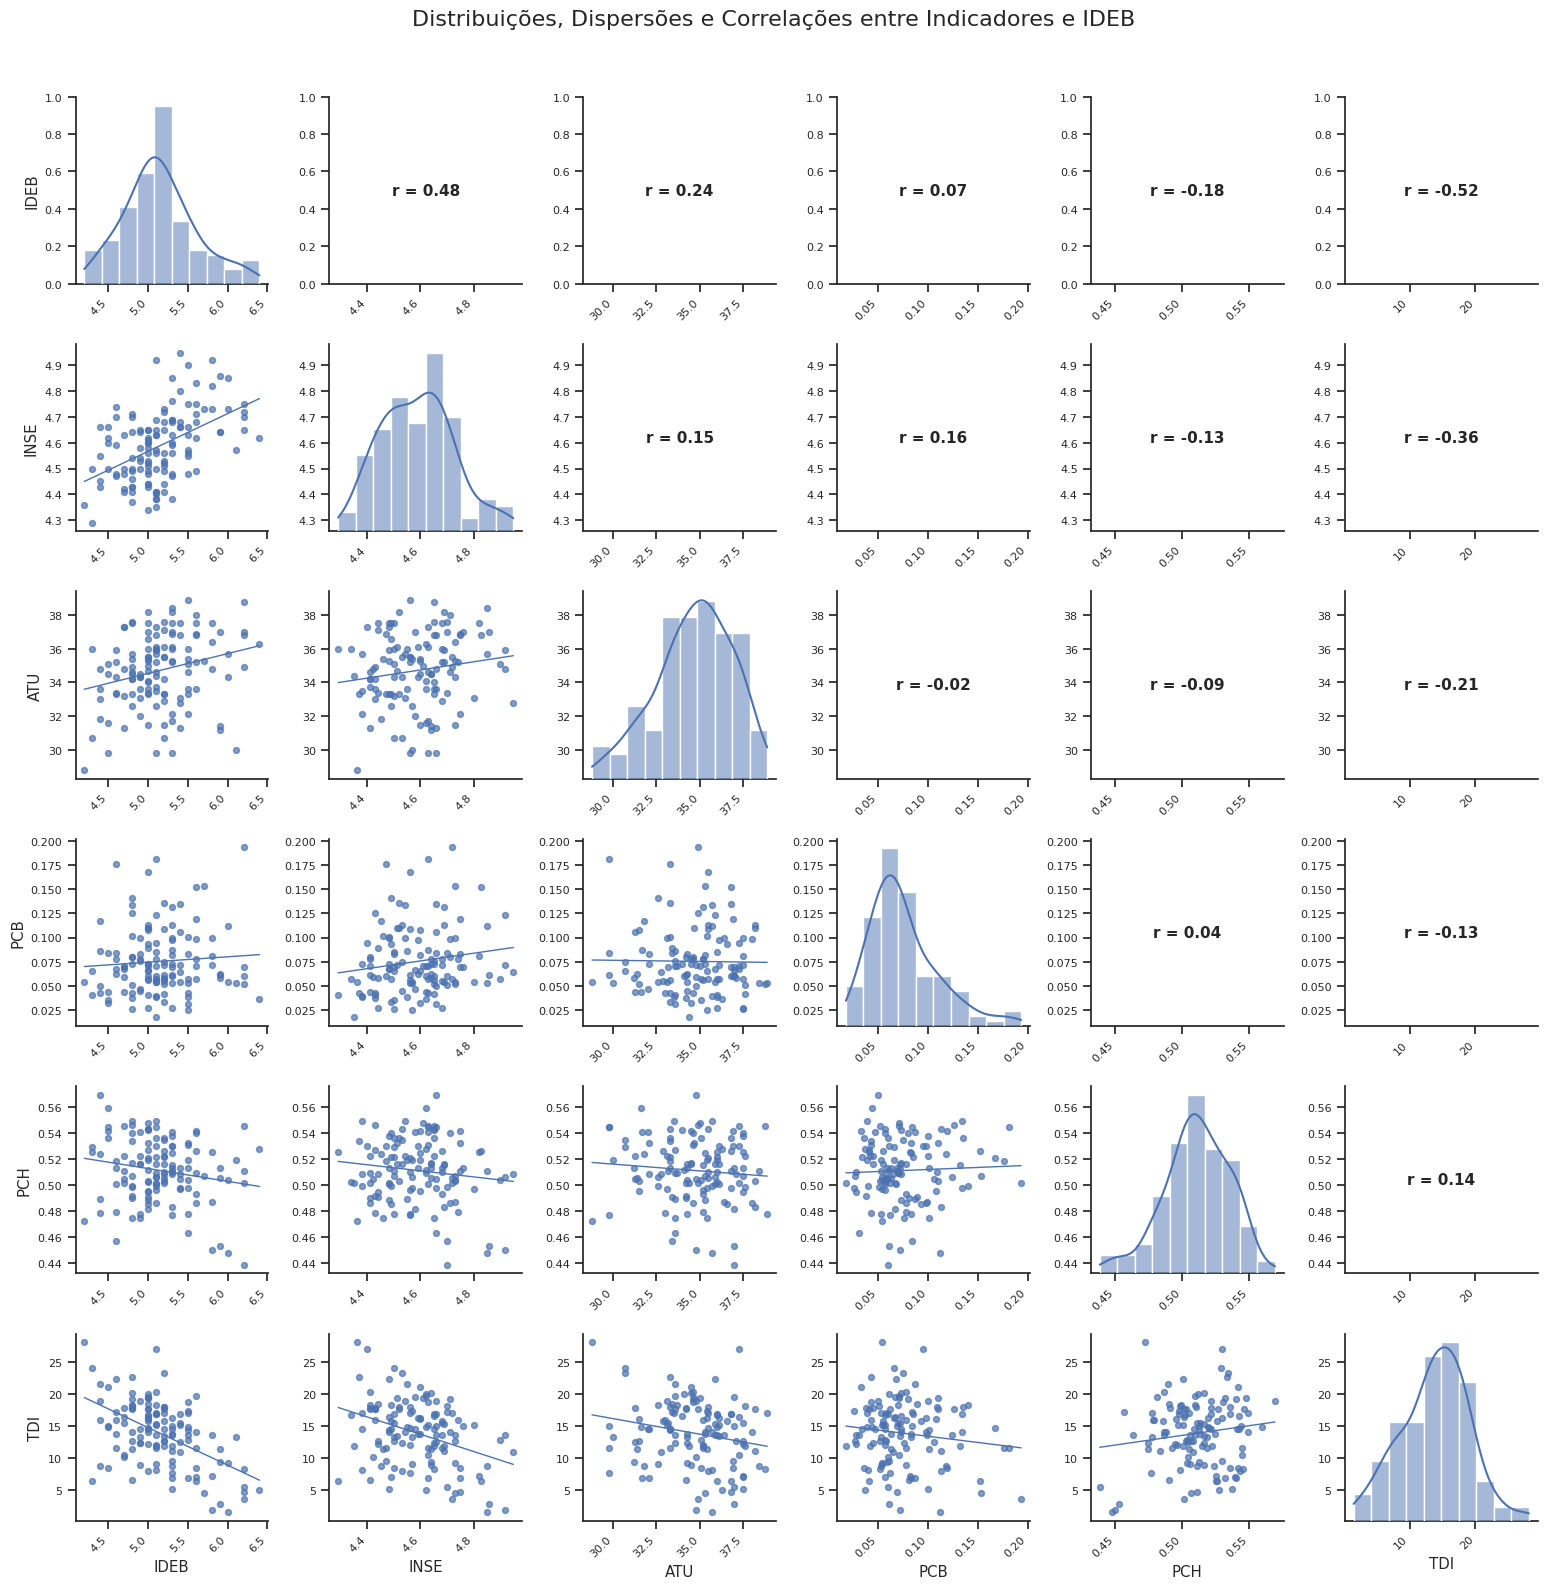

In [ ]:
# =========================
# 1. Carregar base
# =========================
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

# =========================
# 2. Selecionar variáveis
# =========================
variaveis = [
    "IDEB",
    "INSE",
    "ATU",
    "PCB",
    "PCH",
    "TDI"
]

df_plot = df[variaveis].copy()
df_plot = df_plot.apply(pd.to_numeric, errors="coerce")
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna()

# =========================
# 3. Funções do gráfico
# =========================
def grafico_dispersao(x, y, **kws):
    ax = plt.gca()
    sns.regplot(
        x=x, y=y, ci=None,
        scatter_kws={"s": 18, "alpha": 0.7},
        line_kws={"linewidth": 1},
        ax=ax
    )

def grafico_hist(x, **kws):
    ax = plt.gca()
    sns.histplot(x, bins=10, kde=True, ax=ax)

def coef_correlacao(x, y, **kws):
    ax = plt.gca()
    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(
        f"r = {r:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )
    # NÃO apague os ticks aqui

# =========================
# 4. Construir a figura
# =========================
sns.set(style="white", font_scale=0.9)

g = sns.PairGrid(df_plot, diag_sharey=False, height=2.6)
g.map_diag(grafico_hist)
g.map_lower(grafico_dispersao)
g.map_upper(coef_correlacao)

# =========================
# 5. Forçar números em TODOS os eixos
# =========================
for i in range(len(g.axes)):
    for j in range(len(g.axes[i])):
        ax = g.axes[i, j]
        if ax is None:
            continue

        # mostrar marcas e números em todos os painéis
        ax.tick_params(
            axis="x",
            which="both",
            bottom=True,
            top=False,
            labelbottom=True,
            labelsize=8,
            rotation=45
        )
        ax.tick_params(
            axis="y",
            which="both",
            left=True,
            right=False,
            labelleft=True,
            labelsize=8
        )

        # garantir visibilidade dos textos dos ticks
        for label in ax.get_xticklabels():
            label.set_visible(True)
            label.set_rotation(45)
            label.set_ha("right")

        for label in ax.get_yticklabels():
            label.set_visible(True)

g.fig.suptitle(
    "Distribuições, Dispersões e Correlações entre Indicadores e IDEB",
    y=1.02,
    fontsize=16
)

plt.tight_layout()
plt.show()

# ANALISÉ ESTATÍSTICA DOCENTE

In [ ]:
# Caminho da base
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

# Escolha das variáveis
variaveis = [
    "IRD",
    "AFD",
    "IED",
    "DSU"
]

df_sel = df[variaveis]

# Estatísticas
resumo = pd.DataFrame()

resumo["Mínimo"] = df_sel.min()
resumo["Média"] = df_sel.mean()
resumo["Mediana"] = df_sel.median()
resumo["Desvio Padrão"] = df_sel.std()
resumo["Máximo"] = df_sel.max()

# Coeficiente de variação (%)
resumo["Coef. Variação (%)"] = (resumo["Desvio Padrão"] / resumo["Média"]) * 100

# Arredondar
resumo = resumo.round(3)

resumo
#print(resumo)

,Mínimo,Média,Mediana,Desvio Padrão,Máximo,Coef. Variação (%)
IRD,1.431,2.619,2.671,0.426,3.67,16.260
AFD,67.750,92.435,94.145,6.752,100.00,7.304
IED,272.200,380.375,388.800,33.270,453.90,8.747
DSU,61.100,95.571,97.600,5.876,100.00,6.149


# GRÁFICO DE CORRELAÇÃO DOCENTE

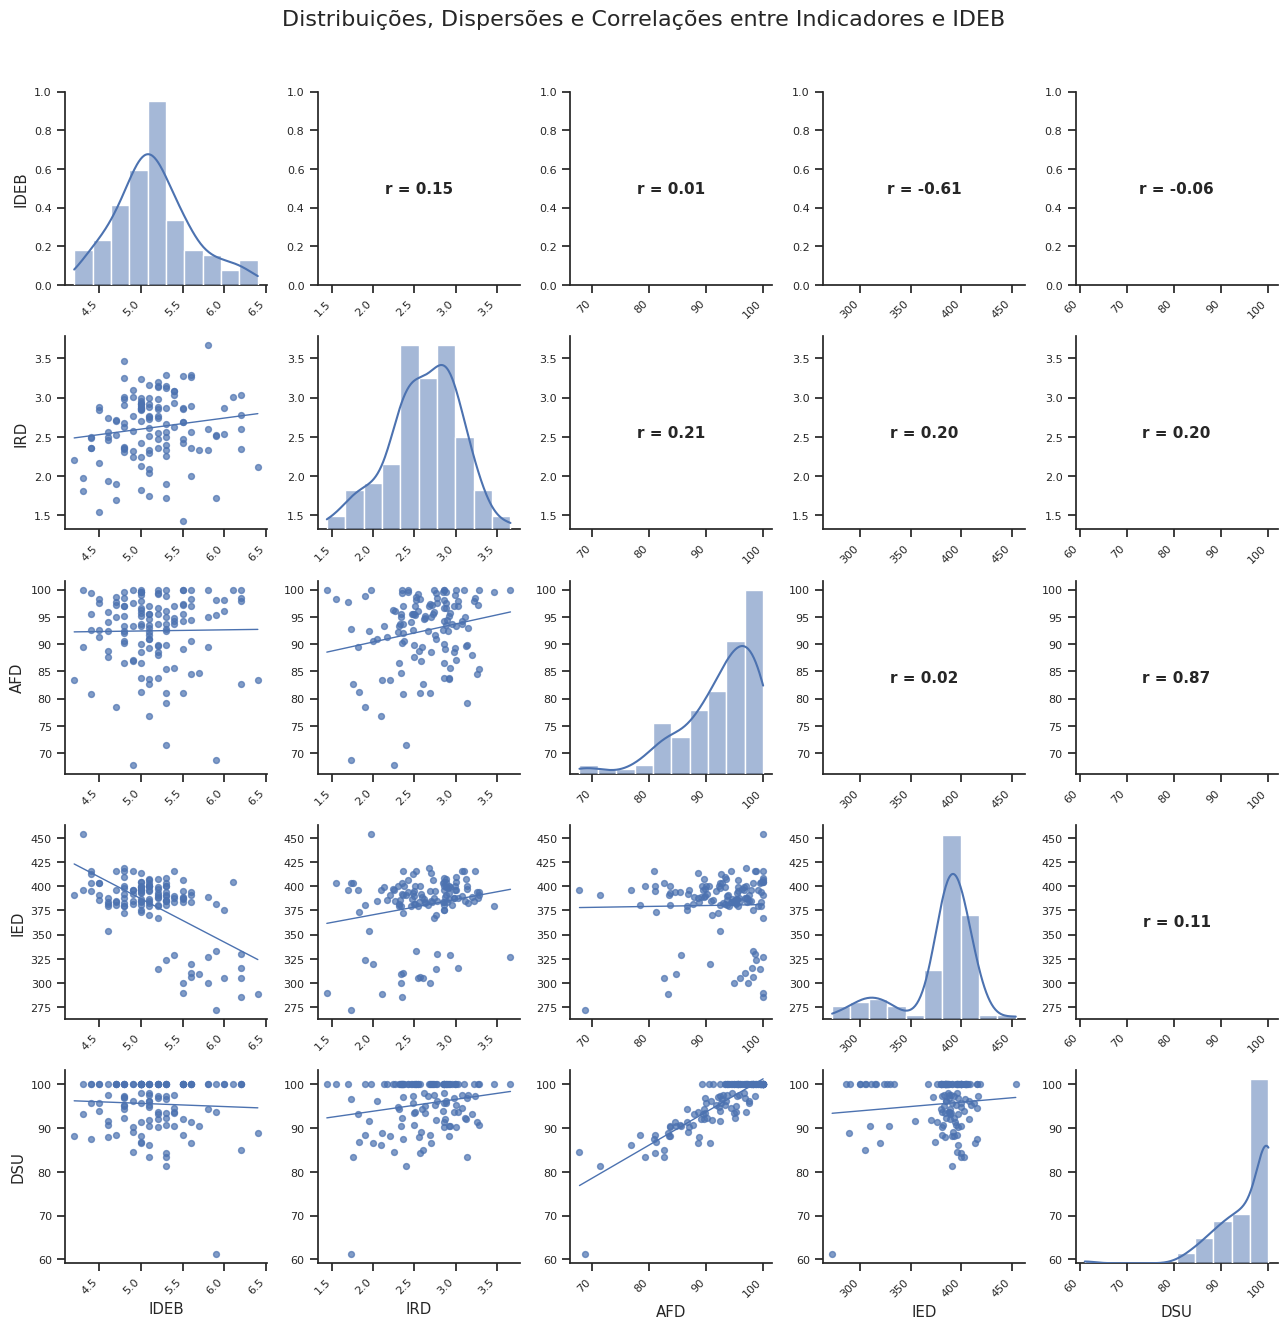

In [ ]:
# =========================
# 1. Carregar base
# =========================
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

# =========================
# 2. Selecionar variáveis
# =========================
variaveis = [
    "IDEB",
    "IRD",
    "AFD",
    "IED",
    "DSU"
]

df_plot = df[variaveis].copy()
df_plot = df_plot.apply(pd.to_numeric, errors="coerce")
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna()

# =========================
# 3. Funções do gráfico
# =========================
def grafico_dispersao(x, y, **kws):
    ax = plt.gca()
    sns.regplot(
        x=x, y=y, ci=None,
        scatter_kws={"s": 18, "alpha": 0.7},
        line_kws={"linewidth": 1},
        ax=ax
    )

def grafico_hist(x, **kws):
    ax = plt.gca()
    sns.histplot(x, bins=10, kde=True, ax=ax)

def coef_correlacao(x, y, **kws):
    ax = plt.gca()
    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(
        f"r = {r:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# =========================
# 4. Construir a figura
# =========================
sns.set(style="white", font_scale=0.9)

g = sns.PairGrid(df_plot, diag_sharey=False, height=2.6)
g.map_diag(grafico_hist)
g.map_lower(grafico_dispersao)
g.map_upper(coef_correlacao)

# =========================
# 5. Forçar números em TODOS os eixos
# =========================
for i in range(len(g.axes)):
    for j in range(len(g.axes[i])):
        ax = g.axes[i, j]
        if ax is None:
            continue

        # mostrar marcas e números em todos os painéis
        ax.tick_params(
            axis="x",
            which="both",
            bottom=True,
            top=False,
            labelbottom=True,
            labelsize=8,
            rotation=45
        )
        ax.tick_params(
            axis="y",
            which="both",
            left=True,
            right=False,
            labelleft=True,
            labelsize=8
        )

        # garantir visibilidade dos textos dos ticks
        for label in ax.get_xticklabels():
            label.set_visible(True)
            label.set_rotation(45)
            label.set_ha("right")

        for label in ax.get_yticklabels():
            label.set_visible(True)

g.fig.suptitle(
    "Distribuições, Dispersões e Correlações entre Indicadores e IDEB",
    y=1.02,
    fontsize=16
)

plt.tight_layout()
plt.show()

# ANALISÉ ESTATÍSTICA ESCOLAR

In [ ]:
# Caminho da base
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

# Escolha das variáveis
variaveis = [
    "HAD",
    "TNR",
    "INF",
    "ICG",
    "REN"
]

df_sel = df[variaveis]

# Estatísticas
resumo = pd.DataFrame()

resumo["Mínimo"] = df_sel.min()
resumo["Média"] = df_sel.mean()
resumo["Mediana"] = df_sel.median()
resumo["Desvio Padrão"] = df_sel.std()
resumo["Máximo"] = df_sel.max()

# Coeficiente de variação (%)
resumo["Coef. Variação (%)"] = (resumo["Desvio Padrão"] / resumo["Média"]) * 100

# Arredondar
resumo = resumo.round(3)

resumo

,Mínimo,Média,Mediana,Desvio Padrão,Máximo,Coef. Variação (%)
HAD,4.900,7.273,6.900,1.195,10.1,16.434
TNR,0.000,2.307,1.500,5.876,66.0,254.675
INF,7.000,9.786,10.000,0.864,11.0,8.825
ICG,2.000,3.595,3.000,1.140,6.0,31.700
REN,0.918,0.989,0.994,0.015,1.0,1.495


# GRÁFICO DE CORRELAÇÃO ESCOLAR

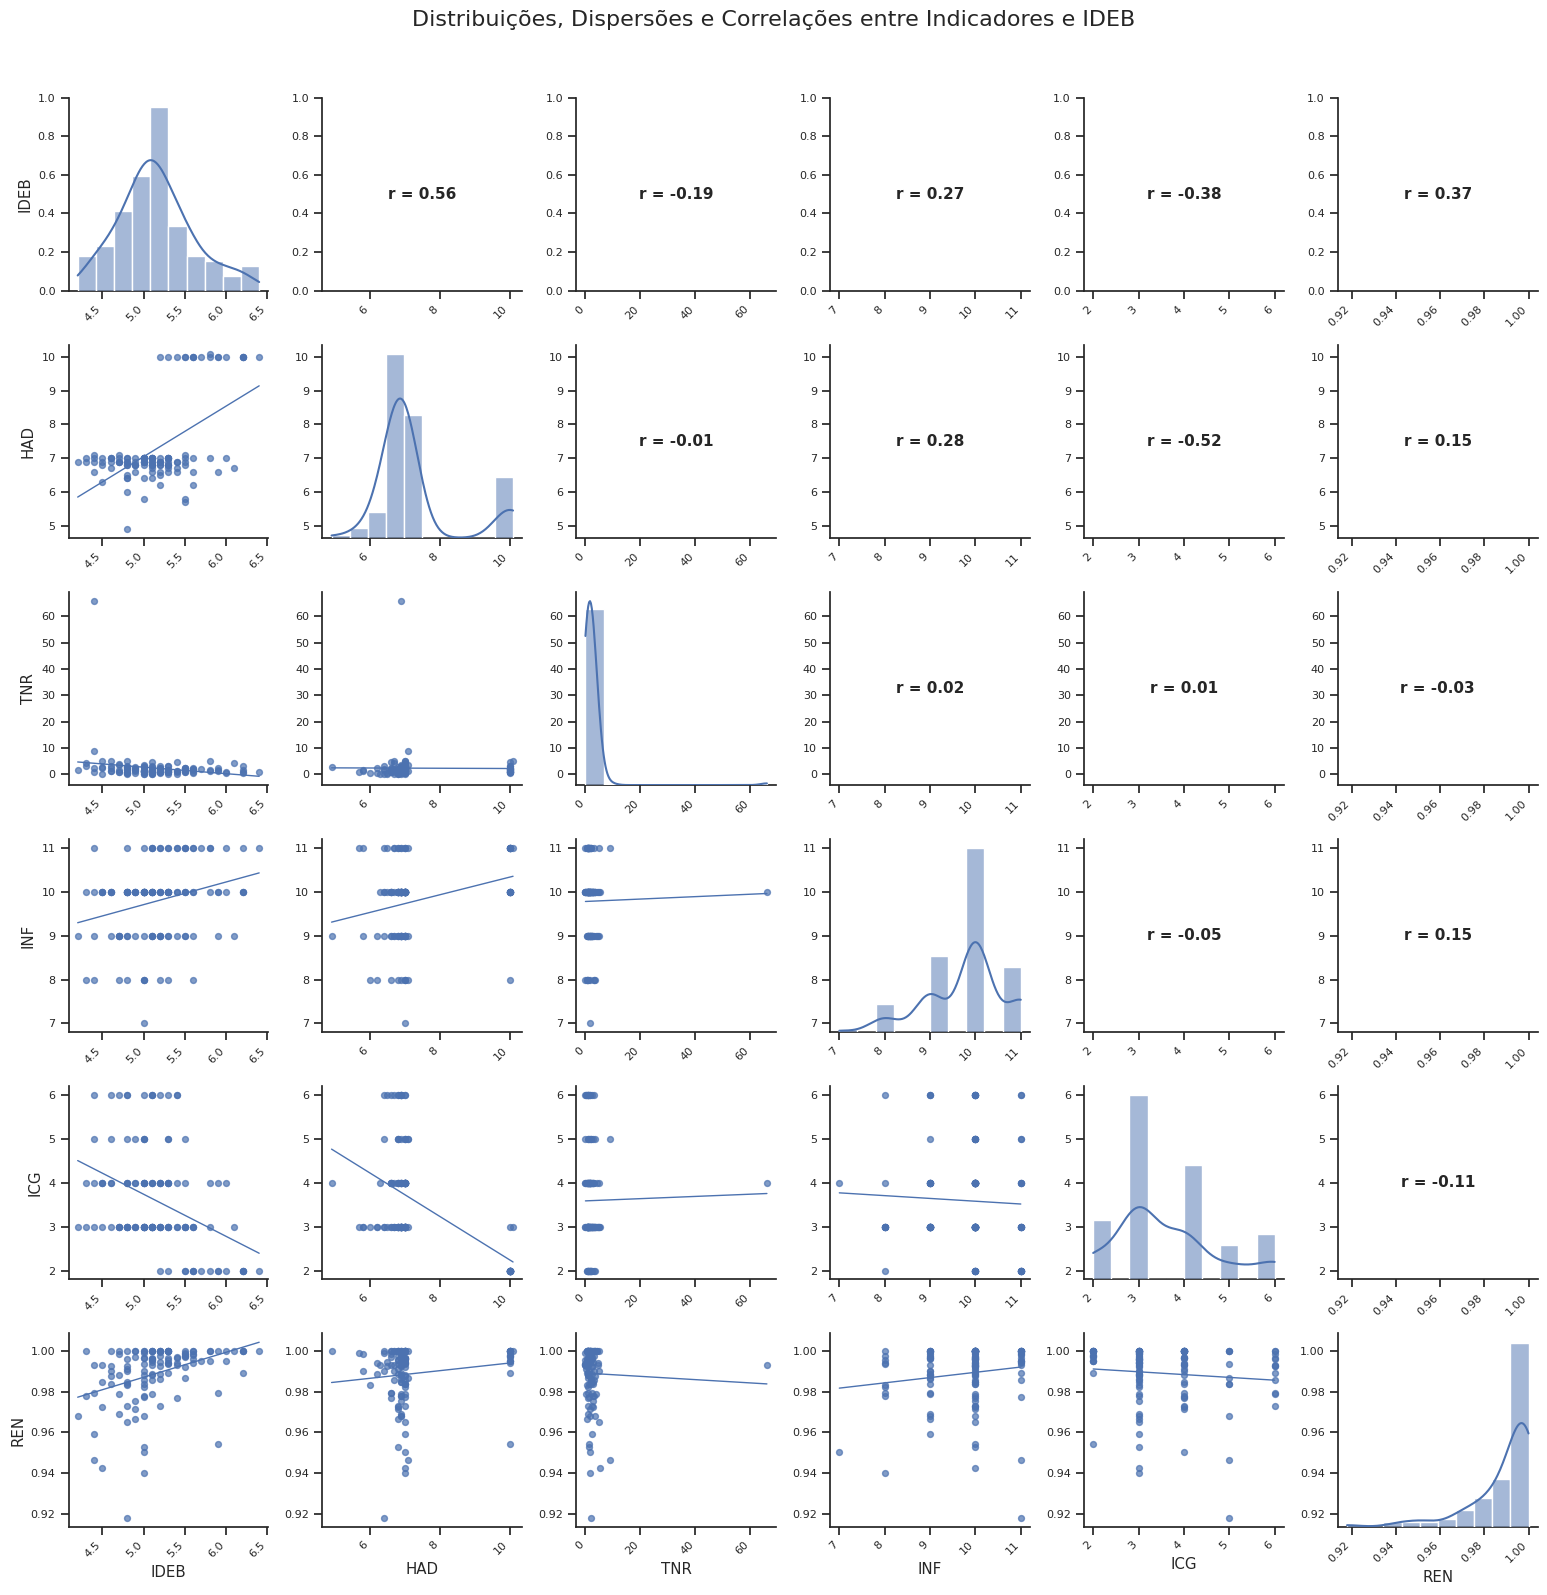

In [ ]:
# =========================
# 1. Carregar base
# =========================
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

# =========================
# 2. Selecionar variáveis
# =========================
variaveis = [
    "IDEB",
     "HAD",
    "TNR",
    "INF",
    "ICG",
    "REN",
]

df_plot = df[variaveis].copy()
df_plot = df_plot.apply(pd.to_numeric, errors="coerce")
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna()

# =========================
# 3. Funções do gráfico
# =========================
def grafico_dispersao(x, y, **kws):
    ax = plt.gca()
    sns.regplot(
        x=x, y=y, ci=None,
        scatter_kws={"s": 18, "alpha": 0.7},
        line_kws={"linewidth": 1},
        ax=ax
    )

def grafico_hist(x, **kws):
    ax = plt.gca()
    sns.histplot(x, bins=10, kde=True, ax=ax)

def coef_correlacao(x, y, **kws):
    ax = plt.gca()
    r = np.corrcoef(x, y)[0, 1]
    ax.annotate(
        f"r = {r:.2f}",
        xy=(0.5, 0.5),
        xycoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )
    # NÃO apague os ticks aqui

# =========================
# 4. Construir a figura
# =========================
sns.set(style="white", font_scale=0.9)

g = sns.PairGrid(df_plot, diag_sharey=False, height=2.6)
g.map_diag(grafico_hist)
g.map_lower(grafico_dispersao)
g.map_upper(coef_correlacao)

# =========================
# 5. Forçar números em TODOS os eixos
# =========================
for i in range(len(g.axes)):
    for j in range(len(g.axes[i])):
        ax = g.axes[i, j]
        if ax is None:
            continue

        # mostrar marcas e números em todos os painéis
        ax.tick_params(
            axis="x",
            which="both",
            bottom=True,
            top=False,
            labelbottom=True,
            labelsize=8,
            rotation=45
        )
        ax.tick_params(
            axis="y",
            which="both",
            left=True,
            right=False,
            labelleft=True,
            labelsize=8
        )

        # garantir visibilidade dos textos dos ticks
        for label in ax.get_xticklabels():
            label.set_visible(True)
            label.set_rotation(45)
            label.set_ha("right")

        for label in ax.get_yticklabels():
            label.set_visible(True)

g.fig.suptitle(
    "Distribuições, Dispersões e Correlações entre Indicadores e IDEB",
    y=1.02,
    fontsize=16
)

plt.tight_layout()
plt.show()

# CORRELAÇÃO GERAL

In [ ]:
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

corr = df.corr(numeric_only=True)

corr["IDEB"].sort_values(ascending=False)

,IDEB
IDEB,1.000000
SPAECE_MEDIA,0.922594
HAD,0.564113
INSE,0.480906
REN,0.373567
INF,0.268981
ATU,0.244279
IRD,0.148788
PCB,0.073262
AFD,0.013870


# CORRELAÇÃO "SEM SPAECE"

In [ ]:
df_modelo = df_modelo.copy()

df_modelo = df_modelo.drop(columns=[
    "SPAECE_MEDIA",
], errors="ignore")

salvar_csv(df_modelo, DADOS_UNIFICADOS, "base_modelo_2023")

Salvo em: /content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS/base_modelo_2023.csv


In [ ]:
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";", encoding="latin1"
)

corr = df.corr(numeric_only=True)

corr["IDEB"].sort_values(ascending=False)

,IDEB
IDEB,1.000000
HAD,0.564113
INSE,0.480906
REN,0.373567
INF,0.268981
ATU,0.244279
IRD,0.148788
PCB,0.073262
AFD,0.013870
DSU,-0.055949


# HEATMAP

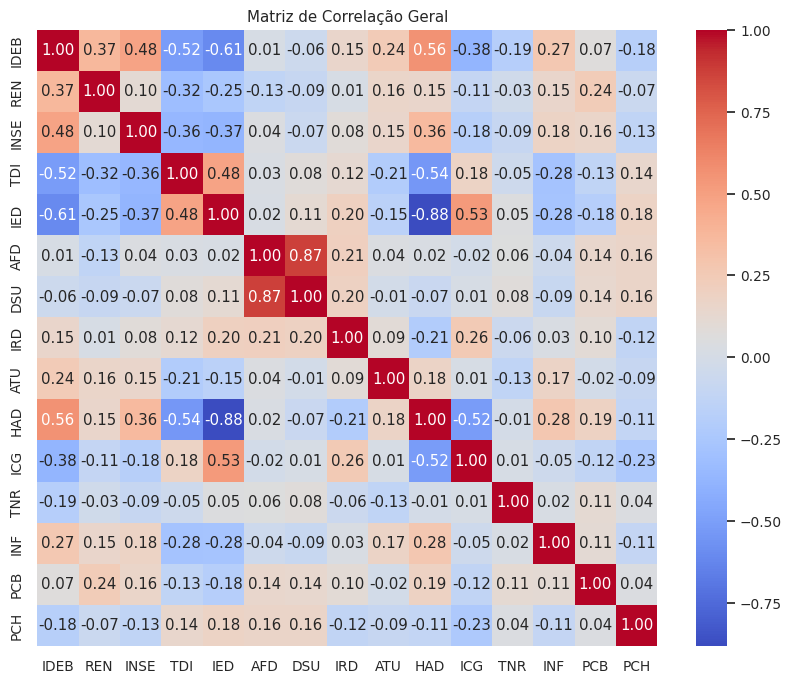

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlação Geral")
plt.show()

# CORRELAÇÃO COM IDEB

In [ ]:
corr_ideb = corr["IDEB"].sort_values(ascending=False)
print(corr_ideb)

IDEB    1.000000
HAD     0.564113
INSE    0.480906
REN     0.373567
INF     0.268981
ATU     0.244279
IRD     0.148788
PCB     0.073262
AFD     0.013870
DSU    -0.055949
PCH    -0.181955
TNR    -0.189762
ICG    -0.379036
TDI    -0.517563
IED    -0.608447
Name: IDEB, dtype: float64


#REGRESSÃO LINEAR MÚLTIPLA PRINCIPAIS CORRELAÇÃO

In [ ]:
import statsmodels.api as sm

variaveis = [
    "HAD",
    "INSE",
    "TDI",
    "IED",
    "ICG",
    "IRD"
]

X = df[variaveis]
y = df["IDEB"]

X = sm.add_constant(X)

In [ ]:
X.isna().sum()

,0
const,0
HAD,0
INSE,0
TDI,0
IED,0
ICG,0
IRD,0


In [ ]:
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   IDEB   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     25.98
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.43e-19
Time:                        11:47:34   Log-Likelihood:                -24.984
No. Observations:                 126   AIC:                             63.97
Df Residuals:                     119   BIC:                             83.82
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3547      1.498      2.907      0.0

In [ ]:
import matplotlib.pyplot as plt

# 1. Ajuste do modelo (conforme você já possui)
modelo = sm.OLS(y, X).fit()

# 2. Configuração da imagem
def salvar_resumo_como_imagem(resumo, nome_arquivo="resultado_regressao.png"):
    # Converte o sumário para string
    texto_resumo = resumo.as_text()

    # Cria a figura com fundo branco
    plt.figure(figsize=(10, 8))
    plt.text(0.01, 0.95, texto_resumo,
             {'fontsize': 10, 'fontfamily': 'monospace'},
             verticalalignment='top')

    # Remove bordas e eixos
    plt.axis('off')

    # Salva com alta resolução (300 DPI é o padrão para artigos)
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Sucesso! Imagem salva como: {nome_arquivo}")

# 3. Execução
salvar_resumo_como_imagem(modelo.summary())


Sucesso! Imagem salva como: resultado_regressao.png


#REGRESSÃO LINEAR MÚLTIPLA P<0,05

In [ ]:
import statsmodels.api as sm

variaveis = [
    "INSE",
    "TDI",
    "IED",
    "ICG",
    "IRD"
]

X = df[variaveis]
y = df["IDEB"]

X = sm.add_constant(X)

In [ ]:
X.isna().sum()

,0
const,0
INSE,0
TDI,0
IED,0
ICG,0
IRD,0


In [ ]:
modelo = sm.OLS(y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   IDEB   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     31.38
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           2.54e-20
Time:                        12:29:28   Log-Likelihood:                -25.046
No. Observations:                 126   AIC:                             62.09
Df Residuals:                     120   BIC:                             79.11
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0331      1.165      3.463      0.0

In [ ]:
import matplotlib.pyplot as plt

# 1. Ajuste do modelo (conforme você já possui)
modelo = sm.OLS(y, X).fit()

# 2. Configuração da imagem
def salvar_resumo_como_imagem(resumo, nome_arquivo="resultado_regressao_limpo.png"):
    # Converte o sumário para string
    texto_resumo = resumo.as_text()

    # Cria a figura com fundo branco
    plt.figure(figsize=(10, 8))
    plt.text(0.01, 0.95, texto_resumo,
             {'fontsize': 10, 'fontfamily': 'monospace'},
             verticalalignment='top')

    # Remove bordas e eixos
    plt.axis('off')

    # Salva com alta resolução (300 DPI é o padrão para artigos)
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Sucesso! Imagem salva como: {nome_arquivo}")

# 3. Execução
salvar_resumo_como_imagem(modelo.summary())

Sucesso! Imagem salva como: resultado_regressao.png


# COEFICIENTES PADRONIZADOS

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_pad = scaler.fit_transform(df[variaveis])
y_pad = scaler.fit_transform(df[["IDEB"]])

X_pad = sm.add_constant(X_pad)

X_pad_df = pd.DataFrame(X_pad, columns=['const'] + variaveis)

# Rodando o modelo com o DataFrame nomeado
modelo_pad = sm.OLS(y_pad, X_pad_df).fit()
print(modelo_pad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     31.38
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           2.54e-20
Time:                        12:32:27   Log-Likelihood:                -126.10
No. Observations:                 126   AIC:                             264.2
Df Residuals:                     120   BIC:                             281.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.708e-16      0.060  -1.45e-14      1.0

In [ ]:
# 2. Configuração da imagem
def salvar_resumo_como_imagem(resumo, nome_arquivo="resultado_regressao_padronizado.png"):
    # Converte o sumário para string
    texto_resumo = resumo.as_text()

    # Cria a figura com fundo branco
    plt.figure(figsize=(10, 8))
    plt.text(0.01, 0.95, texto_resumo,
             {'fontsize': 10, 'fontfamily': 'monospace'},
             verticalalignment='top')

    # Remove bordas e eixos
    plt.axis('off')

    # Salva com alta resolução (300 DPI é o padrão para artigos)
    plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"Sucesso! Imagem salva como: {nome_arquivo}")

# 3. Execução
salvar_resumo_como_imagem(modelo_pad.summary())

Sucesso! Imagem salva como: resultado_regressao_padronizado.png


#VIF (MULTICOLINEARIDADE)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variável"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

  Variável          VIF
0    const  1868.250634
1     INSE     1.269184
2      TDI     1.388180
3      IED     1.859757
4      ICG     1.451401
5      IRD     1.118520


# RESÍDUOS (DIAGNÓSTICO)

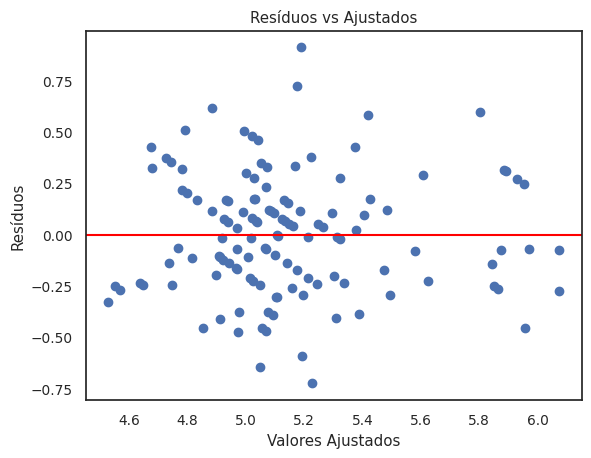

In [ ]:
residuos = modelo.resid
ajustados = modelo.fittedvalues

plt.scatter(ajustados, residuos)
plt.axhline(0, color='red')
plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos")
plt.title("Resíduos vs Ajustados")
plt.show()

# HISTOGRAMA DOS RESÍDUOS

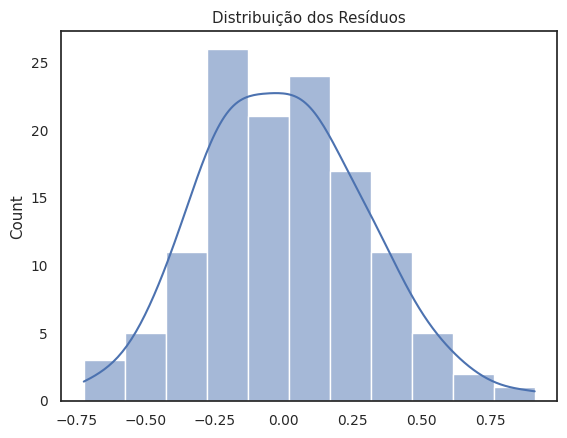

In [ ]:
sns.histplot(residuos, kde=True)
plt.title("Distribuição dos Resíduos")
plt.show()

# QQ Plot (normalidade)

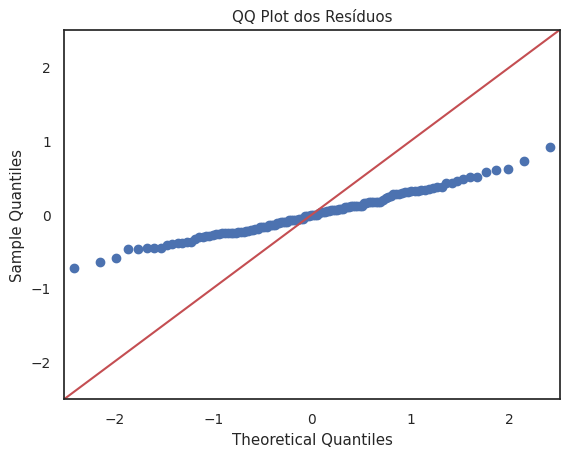

In [ ]:
sm.qqplot(residuos, line='45')
plt.title("QQ Plot dos Resíduos")
plt.show()

#ANÁLISES DE GRUPOS AB

Número de escolas após limpeza: 126

Resumo por grupo:


,grupo,n,media,mediana,desvio_padrao,minimo,maximo,cv
0,0B5A,7,5.743,5.6,0.336,5.4,6.2,5.850
1,1B4A,20,5.665,5.6,0.382,5.0,6.4,6.735
2,2B3A,37,5.111,5.1,0.337,4.6,6.1,6.600
3,3B2A,40,4.988,5.0,0.316,4.4,5.8,6.327
4,4B1A,17,4.841,5.0,0.364,4.2,5.5,7.521
5,5B0A,5,4.920,5.0,0.507,4.4,5.5,10.304



Teste t entre 0B5A e 5B0A:
t = 3.167
p = 0.01750


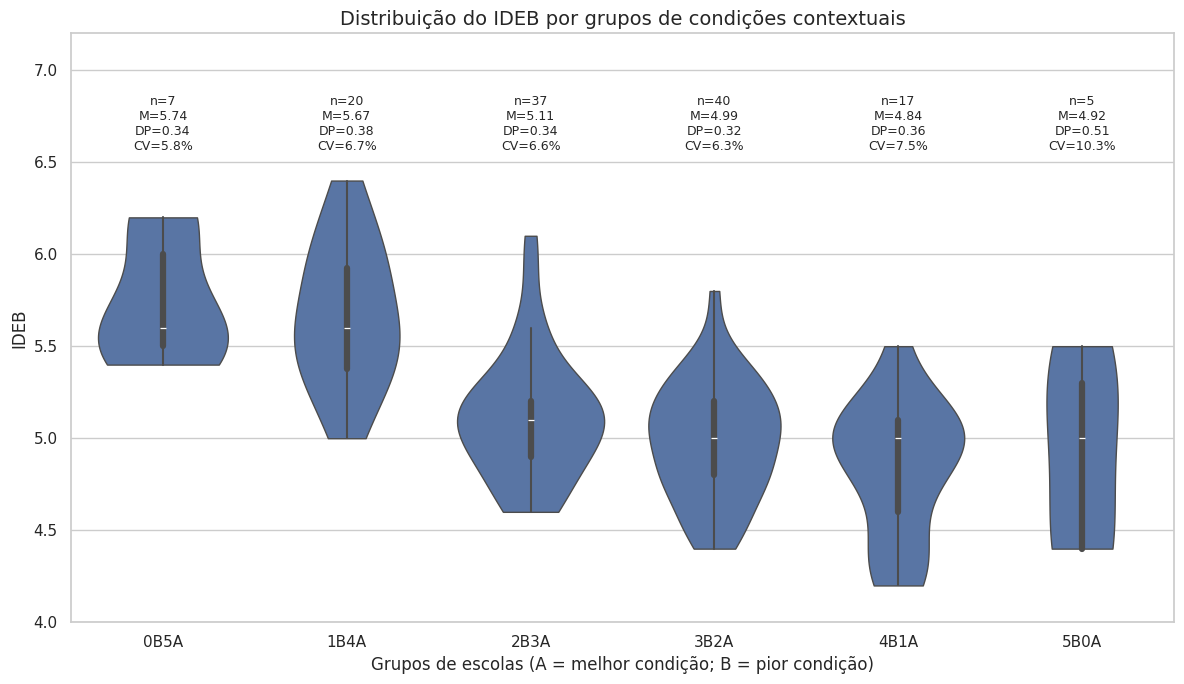

,IDEB,INSE,TDI,IED,ICG,IRD,INSE_AB,TDI_AB,IED_AB,ICG_AB,IRD_AB,A_count,B_count,grupo
0,5.0,4.60,16.0,375.6,3,2.857899,A,B,A,A,A,4,1,1B4A
1,5.2,4.52,18.0,314.2,2,2.764550,B,B,A,A,A,3,2,2B3A
2,5.3,4.38,14.5,390.7,5,2.394396,B,B,B,B,B,0,5,5B0A
3,5.3,4.76,14.9,394.6,5,3.285143,A,B,B,B,A,2,3,3B2A
4,5.3,4.48,5.1,323.6,2,1.897302,B,A,A,A,B,3,2,2B3A


In [ ]:
from scipy.stats import ttest_ind

# =========================================================
# 2. Caminho da base
# =========================================================
BASE_DIR = "/content/analise-ideb-2023-fortaleza/dados/DADOS_UNIFICADOS"

df = pd.read_csv(
    os.path.join(BASE_DIR, "base_modelo_2023.csv"),
    sep=";",
    encoding="latin1"
)

# =========================================================
# 3. Seleção das variáveis para formar os grupos
#    Ajuste esta lista conforme sua análise
# =========================================================
variaveis = ["INSE", "TDI", "IED", "ICG", "IRD"]

# Variável dependente
var_dep = "IDEB"

# =========================================================
# 4. Base auxiliar
# =========================================================
df_ab = df[[var_dep] + variaveis].copy()

# Garantir numérico e remover linhas incompletas
df_ab = df_ab.apply(pd.to_numeric, errors="coerce")
df_ab = df_ab.replace([np.inf, -np.inf], np.nan).dropna().copy()

print("Número de escolas após limpeza:", len(df_ab))

# =========================================================
# 5. Classificação A/B pela mediana
#
# Regra:
# - maior = melhor: INSE, IRD
# - menor = melhor: TDI, IED, ICG
# =========================================================
variaveis_maior_melhor = ["INSE", "IRD"]
variaveis_menor_melhor = ["TDI", "IED", "ICG"]

for var in variaveis:
    mediana = df_ab[var].median()

    if var in variaveis_maior_melhor:
        df_ab[var + "_AB"] = df_ab[var].apply(lambda x: "A" if x >= mediana else "B")
    elif var in variaveis_menor_melhor:
        df_ab[var + "_AB"] = df_ab[var].apply(lambda x: "A" if x <= mediana else "B")
    else:
        raise ValueError(f"Defina a lógica de classificação para a variável: {var}")

# =========================================================
# 6. Contagem de A e B
# =========================================================
colunas_ab = [v + "_AB" for v in variaveis]

df_ab["A_count"] = df_ab[colunas_ab].apply(lambda x: (x == "A").sum(), axis=1)
df_ab["B_count"] = df_ab[colunas_ab].apply(lambda x: (x == "B").sum(), axis=1)

# Nome do grupo
df_ab["grupo"] = df_ab["B_count"].astype(str) + "B" + df_ab["A_count"].astype(str) + "A"

# =========================================================
# 7. Ordenar grupos
# =========================================================
n_vars = len(variaveis)

ordem = [f"{b}B{n_vars-b}A" for b in range(0, n_vars + 1)]
df_ab["grupo"] = pd.Categorical(df_ab["grupo"], categories=ordem, ordered=True)

# =========================================================
# 8. Estatísticas descritivas por grupo
# =========================================================
resumo_grupos = df_ab.groupby("grupo", observed=False)[var_dep].agg(
    n="count",
    media="mean",
    mediana="median",
    desvio_padrao="std",
    minimo="min",
    maximo="max"
).reset_index()

resumo_grupos["cv"] = (resumo_grupos["desvio_padrao"] / resumo_grupos["media"]) * 100
resumo_grupos = resumo_grupos.round(3)

print("\nResumo por grupo:")
display(resumo_grupos)

# Salvar tabela
resumo_grupos.to_csv(
    os.path.join(BASE_DIR, "resumo_grupos_contexto.csv"),
    sep=";",
    encoding="latin1",
    index=False
)

# =========================================================
# 9. Teste t entre grupos extremos
# =========================================================
grupo_melhor = ordem[0]      # ex.: 0B5A
grupo_pior = ordem[-1]       # ex.: 5B0A

dados_melhor = df_ab.loc[df_ab["grupo"] == grupo_melhor, var_dep]
dados_pior = df_ab.loc[df_ab["grupo"] == grupo_pior, var_dep]

if len(dados_melhor) > 1 and len(dados_pior) > 1:
    t_stat, p_val = ttest_ind(dados_melhor, dados_pior, equal_var=False, nan_policy="omit")
    print(f"\nTeste t entre {grupo_melhor} e {grupo_pior}:")
    print(f"t = {t_stat:.3f}")
    print(f"p = {p_val:.5f}")
else:
    print(f"\nNão foi possível realizar o teste t entre {grupo_melhor} e {grupo_pior} por falta de casos suficientes.")

# =========================================================
# 10. Gráfico de violino
# =========================================================
sns.set(style="whitegrid", font_scale=1.0)

plt.figure(figsize=(12, 7))

ax = sns.violinplot(
    data=df_ab,
    x="grupo",
    y=var_dep,
    inner="box",
    cut=0,
    linewidth=1
)

plt.title("Distribuição do IDEB por grupos de condições contextuais", fontsize=14)
plt.xlabel("Grupos de escolas (A = melhor condição; B = pior condição)", fontsize=12)
plt.ylabel("IDEB", fontsize=12)

# =========================================================
# 11. Adicionar estatísticas no gráfico
# =========================================================
# Posição do texto acima de cada violino
y_max = df_ab[var_dep].max()

for i, row in resumo_grupos.iterrows():
    grupo = row["grupo"]
    n = row["n"]
    media = row["media"]
    dp = row["desvio_padrao"]
    cv = row["cv"]

    # só adiciona texto em grupos com observações
    if n > 0:
        texto = f"n={n}\nM={media:.2f}\nDP={dp:.2f}\nCV={cv:.1f}%"
        plt.text(
            i,
            y_max + 0.15,
            texto,
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.ylim(df_ab[var_dep].min() - 0.2, y_max + 0.8)
plt.tight_layout()

# Salvar figura
plt.savefig(
    os.path.join(BASE_DIR, "violino_grupos_contexto_IDEB.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# 12. Visualizar base final com grupos
# =========================================================
display(df_ab.head())